In [1]:
#20-10-25 - RH - ta - Optimized models
#use a smaller dataset to expedite the process of finding the optimal parameters and then use the optimal models on larger datasets
#So, sample_frac = 0.001 (0.1% of the data per height) and for ht in range(32, 91, 7).


import time
overall_start_time = time.time()
import os
import sys

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

# import json_file_editer as JFE
from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

#################################################################
Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

options_json=JFE.get_json_data("options.json")
options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
ds = dataset_init.ds_init_3d(myJob, chunks={}) 

The job folder path : ./output/Log_ML.txt
2025 Oct 20 13:57:09 > Log nicely initialized 
2025 Oct 20 13:57:09 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2025 Oct 20 13:57:09 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001
2025 Oct 20 13:57:09 > (DI0021) Found 8 time-varying files in date range
2025 Oct 20 13:57:09 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0001/pod0001_atm_vgrid_ml.nc
2025 Oct 20 13:57:10 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2025 Oct 20 13:57:10 > (DI0024) Dimensions in vgrid: FrozenMappingWarningOnValuesAccess({'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60})
2025 Oct 20 13:57:10 > (DI0037) Loading horizonta

In [2]:
seed = 1
sample_frac = 0.001 

ht=31
data=ds.sel(height=ht, height_2=ht) 

total = data['clw'] + data['cli']
data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
for ht in range(32, 91, 1): #(32, 91, 3)
    data = ds.sel(height=ht, height_2=ht)

    total = data['clw'] + data['cli']
    data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
    data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe().sample(frac=sample_frac, random_state= seed+ht)
    dfs.append(df_sampled) 

df = pd.concat(dfs, ignore_index=True)

# print('length of dfs: ',len(dfs))
# print('len of dfs[0]: ', len(dfs[0]))
prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))

Expected length of df:  1258320
Final length of df:  1258320


In [3]:
threshold = 5e-12
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]
# print('df- After threshold-1:')
# print(df_new)
if df_new.empty:
    df_new = df

df = df_new
# print('df after threshold-2:\n', df)

In [4]:
#RH from SH
def RH_from_SH(pfull, hus, ta, T_0= 273.16):
    RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
    return RH

In [5]:
df['RH']=RH_from_SH(df['pfull'], df['hus'], df['ta'])

In [6]:
count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("incorrect count = ", count)
print("incorrect count percent = ", 100*count/len(df['RH']))

incorrect count =  2266
incorrect count percent =  0.7028753993610224


In [7]:
df['RH']= df['RH'].clip(lower=0, upper=100)

In [8]:
col=df.pop('RH')
df.insert(16, 'RH', col) #hus is at 15th position
df.pop('hus')

df['clw+cli']=df['clw']+df['cli']

col=df.pop('clw+cli')
df.insert(25, 'clw+cli', col) 

# df.to_csv("df.csv", index=False)
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)',
       'qg/(qr+qs+qg)'],
      dtype='object')

In [9]:
#Include 'cloud liquid water path + cloud ice path' as a feature.

df['cllvi+clivi']=df['cllvi']+df['clivi']

col=df.pop('cllvi+clivi')
df.insert(26, 'cllvi+clivi', col) 

# df.to_csv("df.csv", index=False)
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'RH', 'ta', 'wa', 'rho',
       'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli',
       'cllvi+clivi', 'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)',
       'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)'],
      dtype='object')

In [10]:
df.tail()

,clon,clat,cell_area,pr,tas,clivi,cllvi,qgvi,qrvi,qsvi,...,pfull,height,height_2,clw+cli,cllvi+clivi,clw/(clw+cli),cli/(clw+cli),qr/(qr+qs+qg),qs/(qr+qs+qg),qg/(qr+qs+qg)
1258304,-0.458523,-0.138792,2.426932e+07,-4.917857e-10,NaN,7.140413e-10,0.033093,3.568486e-12,1.965763e-06,1.111592e-11,...,101332.468750,90.0,90.0,2.408146e-11,0.033093,0.999988,1.181643e-05,0.000000,6.936438e-01,3.063561e-01
1258305,1.798867,0.587646,2.295074e+07,5.525636e-07,NaN,2.528751e-02,0.010375,5.933870e-05,4.518208e-07,8.899687e-03,...,65956.109375,90.0,90.0,7.175943e-05,0.035662,0.987934,1.206610e-02,0.019146,4.791678e-01,5.016866e-01
1258308,-0.283196,-0.630255,2.430943e+07,-1.454472e-09,NaN,1.750356e-04,0.149973,9.384019e-09,9.711319e-06,3.520425e-05,...,102405.750000,90.0,90.0,8.562572e-10,0.150148,1.000000,3.525563e-07,0.000000,5.891995e-01,4.108005e-01
1258313,-1.642741,-0.944314,2.490149e+07,4.814016e-06,NaN,2.985019e-03,1.396195,2.531676e-05,1.388432e-02,1.109809e-03,...,99273.843750,90.0,90.0,1.087786e-07,1.399180,1.000000,4.768792e-09,1.000000,6.696911e-11,6.582442e-11
1258319,-0.703851,0.162303,2.407235e+07,-2.062221e-13,NaN,8.051683e-08,0.015935,2.730509e-12,6.733629e-10,7.281679e-09,...,101331.882812,90.0,90.0,1.272582e-11,0.015935,0.999976,2.417251e-05,0.000000,5.886445e-01,4.113556e-01


In [11]:
# print("Description of the df:\n")
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].describe())
# print(df[['cli', 'clw', 'qr', 'qg', 'qs']].isna().sum())
# print("Description ends\n")

# split data into X and y
# X = df.iloc[:, [15,16]].values # RH, ta
X = df.iloc[:, [0,1,15,16,17,18,19,20,21,22,23,24,25,26]].values 

y = df.iloc[:,-5].values #y is clw/(clw+cli)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

cols= [0,1,15,16,17,18,19,20,21,22,23,24,25,26]
feature_names=df.columns[cols].tolist()
print(feature_names)

['clon', 'clat', 'RH', 'ta', 'wa', 'rho', 'dzghalf', 'ua', 'va', 'pfull', 'height', 'height_2', 'clw+cli', 'cllvi+clivi']


In [12]:
#This is df and not X_train
print('RH min: ', df['RH'].min())
print('RH max: ', df['RH'].max())
print('\n')
print('ta min: ', df['ta'].min())
print('ta max: ', df['ta'].max())
print('\n')
print('pfull min: ', df['pfull'].min())
print('pfull max: ', df['pfull'].max())
print('\n')
print('wa min: ', df['wa'].min())
print('wa max: ', df['wa'].max())
print('\n')

RH min:  0.0044398652
RH max:  100.0


ta min:  183.04462
ta max:  301.35934


pfull min:  2869.6233
pfull max:  103709.31


wa min:  -4.886416
wa max:  10.870216




In [13]:
print(len(y_train))
print(len(y_test))

257912
64478


Decision Tree


Max. Validation R2 score: 0.9280935284385683 is at depth (bestDepth): 8


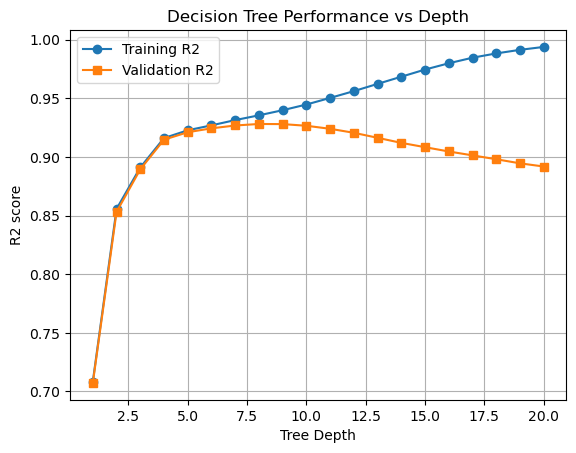

In [14]:
#Medium
#Use Cross-Validation
#best depth acc. to val data

train_r2_scores=[]
val_r2_scores=[]
depths=range(1,21) #This seemed a reasonable depth range which is obtained from trial and error and articles online
for depth in depths:
    tree=DTR(max_depth=depth, random_state=1)
    #train
    tree.fit(X_train,y_train)
    train_score=tree.score(X_train, y_train)
    train_r2_scores.append(train_score)
    # print(f"Depth {depth}: Training R2 score = {train_score} ") 

    #val
    
    val_scores= cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
    # print(f"Depth {depth}: Mean Validation R2 score = {val_scores.mean()} ") #val_scores.mean(): .4f
    val_r2_scores.append(val_scores.mean())

#print(type(val_scores)) #<class 'numpy.ndarray'>
#print(val_scores)
max_val_r2_score=max(val_r2_scores)
bestDepth=depths[val_r2_scores.index(max_val_r2_score)]
print(f"\nMax. Validation R2 score: {max_val_r2_score} is at depth (bestDepth): {bestDepth}") #Validation R2 score is different from Test R2 score

#Plotting
plt.figure() #figsize=(8,5)
plt.plot(depths, train_r2_scores, marker='o', label='Training R2')
plt.plot(depths, val_r2_scores, marker='s', label='Validation R2')
plt.xlabel("Tree Depth")
plt.ylabel("R2 score")
plt.title("Decision Tree Performance vs Depth")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#to find the best Depth and the best number of min samples in leaf
depths = range(1, 21) #range(1, 21)
min_samples_in_leaf = range(1, 41) #range(1,51)

train_r2_scores = []
val_r2_scores = []
param_combinations = []

best_val_score = -np.inf
best_depth = None
best_min_samples_leaf = None

for depth in depths:
    for min_samples in min_samples_in_leaf:
        tree = DTR(max_depth=depth, min_samples_leaf=min_samples, random_state=1)

        tree.fit(X_train, y_train)
        train_score = tree.score(X_train, y_train)
      
        val_scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='r2')
        val_mean = val_scores.mean()
       
        train_r2_scores.append(train_score)
        val_r2_scores.append(val_mean)
        param_combinations.append((depth, min_samples))

        if val_mean > best_val_score:
            best_val_score = val_mean
            best_depth = depth
            best_min_samples_leaf = min_samples

print(f"\nBest Validation R2 Score: {best_val_score: }")
print(f"Best Parameters: max_depth={best_depth}, min_samples_leaf={best_min_samples_leaf}")

#took 48 mins to run

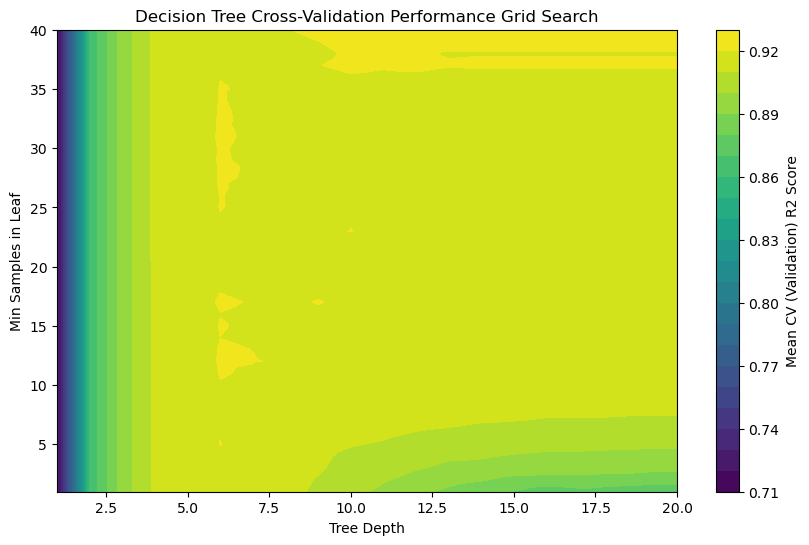

In [ ]:
param_combinations = np.array(param_combinations)
depths_arr = param_combinations[:, 0]
min_samples_arr = param_combinations[:, 1]
val_r2_scores = np.array(val_r2_scores)


plt.figure(figsize=(10, 6))
plt.tricontourf(depths_arr, min_samples_arr, val_r2_scores, levels=20, cmap='viridis')
plt.colorbar(label="Mean CV (Validation) R2 Score")
plt.xlabel("Tree Depth")
plt.ylabel("Min Samples in Leaf")
plt.title("Decision Tree Cross-Validation Performance Grid Search")
plt.show()


[Text(0.5363909841954023, 0.9666666666666667, 'ta <= 270.831\nsquared_error = 0.199\nsamples = 38514\nvalue = 0.282'),
 Text(0.3740301724137931, 0.9, 'RH <= 97.98\nsquared_error = 0.043\nsamples = 27892\nvalue = 0.049'),
 Text(0.4552105783045977, 0.9333333333333333, 'True  '),
 Text(0.29030172413793104, 0.8333333333333334, 'ta <= 264.9\nsquared_error = 0.018\nsamples = 26954\nvalue = 0.021'),
 Text(0.20474137931034483, 0.7666666666666667, 'ta <= 262.318\nsquared_error = 0.003\nsamples = 24677\nvalue = 0.004'),
 Text(0.12902298850574712, 0.7, 'RH <= 96.546\nsquared_error = 0.002\nsamples = 23962\nvalue = 0.002'),
 Text(0.12442528735632184, 0.6333333333333333, 'RH <= 94.745\nsquared_error = 0.002\nsamples = 23911\nvalue = 0.002'),
 Text(0.11982758620689656, 0.5666666666666667, 'ta <= 251.164\nsquared_error = 0.001\nsamples = 23857\nvalue = 0.002'),
 Text(0.05, 0.5, 'ta <= 248.816\nsquared_error = 0.0\nsamples = 20217\nvalue = 0.0'),
 Text(0.021839080459770115, 0.43333333333333335, 'RH <=

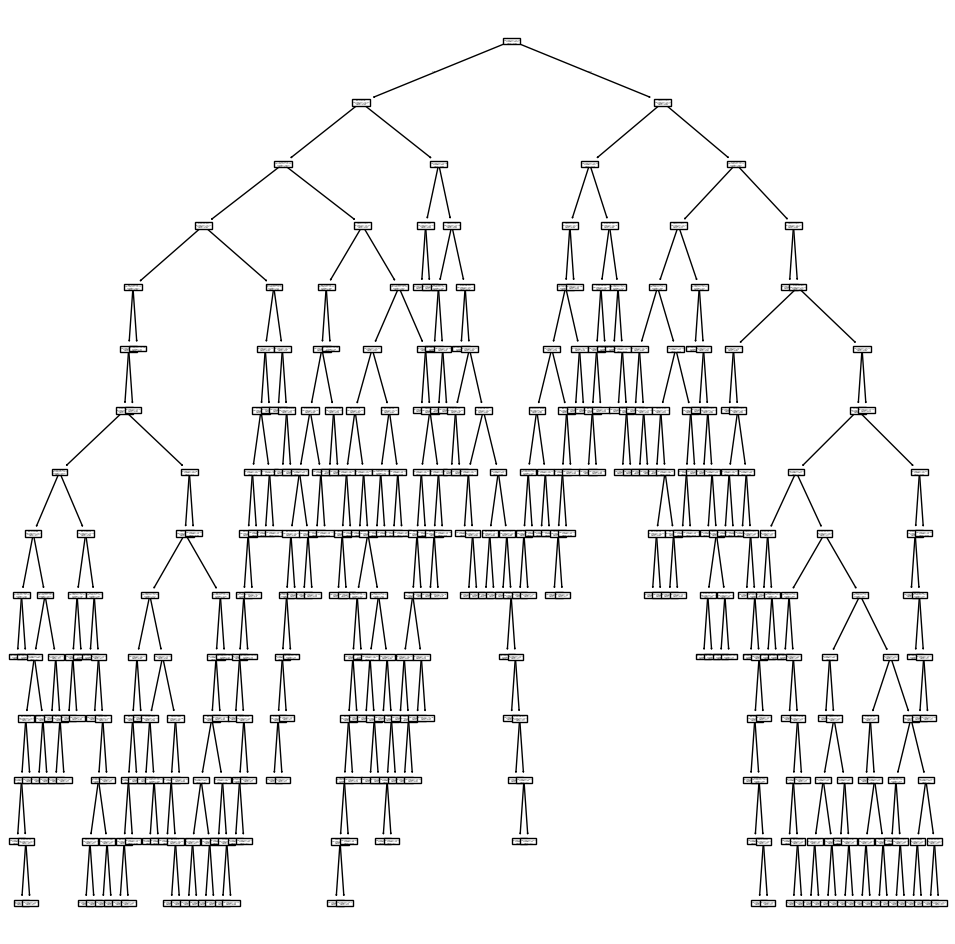

In [ ]:
#Pathway-1

reg=DTR(max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, random_state=0)
reg.fit(X_train, y_train)
ax=subplots(figsize=(12,12))[1]
plot_tree(reg, feature_names=feature_names, ax=ax)

In [ ]:
#Pathway-1
#This seems more robust because it uses CV and not test data to determine the best ccp_alpha

ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)

kfold = skm.KFold(5,
shuffle=True,
random_state=10)

grid = skm.GridSearchCV(reg,
{'ccp_alpha': ccp_path.ccp_alphas},
refit=True,
cv=kfold,
scoring='r2',
n_jobs=-1)

G = grid.fit(X_train, y_train)

best_ = grid.best_estimator_
print(best_)

depth = best_.get_depth()
print(depth)

DecisionTreeRegressor(ccp_alpha=np.float64(3.206218335502584e-05), max_depth=14,
                      min_samples_leaf=40, random_state=0)
10


[Text(0.5347877358490566, 0.9545454545454546, 'ta <= 270.831\nsquared_error = 0.199\nsamples = 38514\nvalue = 0.282'),
 Text(0.3313679245283019, 0.8636363636363636, 'RH <= 97.98\nsquared_error = 0.043\nsamples = 27892\nvalue = 0.049'),
 Text(0.43307783018867924, 0.9090909090909092, 'True  '),
 Text(0.1721698113207547, 0.7727272727272727, 'ta <= 264.9\nsquared_error = 0.018\nsamples = 26954\nvalue = 0.021'),
 Text(0.07547169811320754, 0.6818181818181818, 'ta <= 262.318\nsquared_error = 0.003\nsamples = 24677\nvalue = 0.004'),
 Text(0.03773584905660377, 0.5909090909090909, 'RH <= 96.546\nsquared_error = 0.002\nsamples = 23962\nvalue = 0.002'),
 Text(0.018867924528301886, 0.5, 'squared_error = 0.002\nsamples = 23911\nvalue = 0.002'),
 Text(0.05660377358490566, 0.5, 'squared_error = 0.155\nsamples = 51\nvalue = 0.254'),
 Text(0.11320754716981132, 0.5909090909090909, 'pfull <= 85605.273\nsquared_error = 0.05\nsamples = 715\nvalue = 0.069'),
 Text(0.09433962264150944, 0.5, 'squared_error = 0

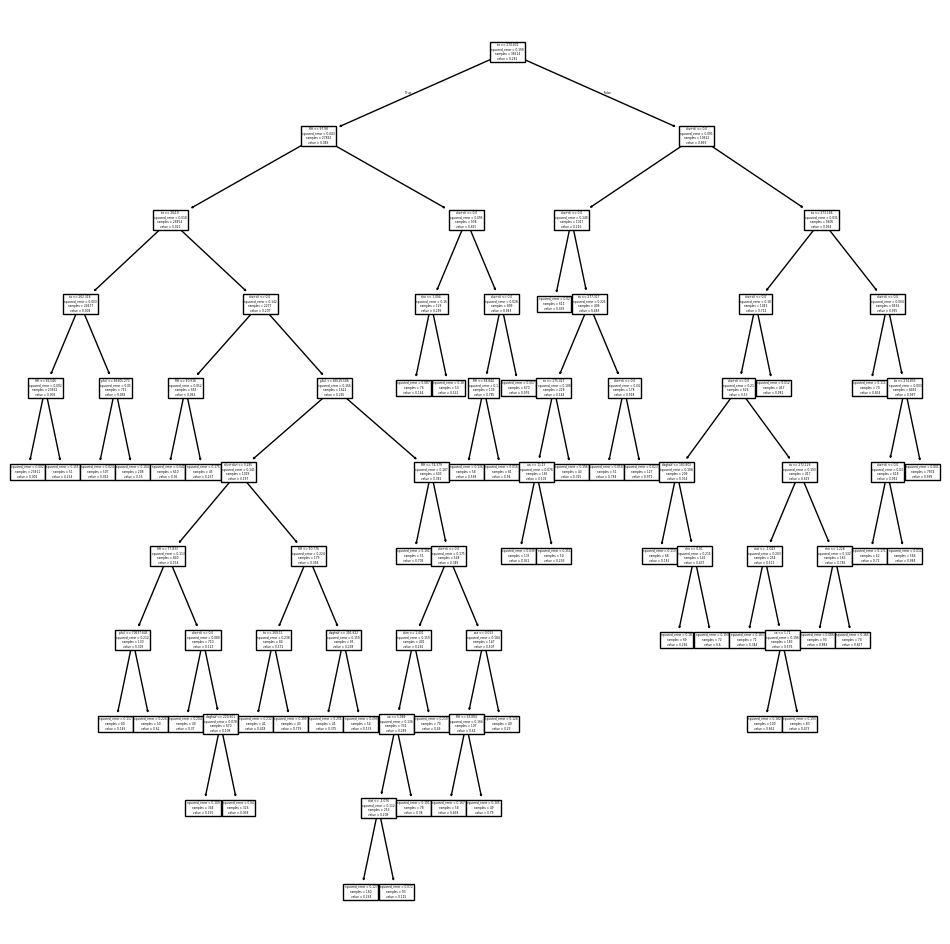

In [ ]:
#Pathway-1
#Plot the best tree
ax= subplots(figsize=(12,12))[1]
plot_tree(G.best_estimator_, feature_names=feature_names, ax=ax) #after ccp

In [ ]:
##Training
# training_start_time = time.time()
# best_.fit(X_train, y_train) #redundant
# training_end_time = time.time()
# training_elapsed_time = training_end_time - training_start_time
# print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = best_.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

#########################################
print('size of y_pred: ', len(y_pred))

#Clipping (which is done below) is redundant as Decision Tree produces exact output values, which are in the input range.

# count=0
# for i in y_pred:
#     if(i>1 or i<0):
#         # print(i)
#         count+=1

# print('size of off-numbers: ', count)
# print('percentage of off-numbers: ', 100*count/len(y_pred))
# #########################################
# y_pred = np.clip(y_pred, 0, 1)

Prediction- Elapsed time: 0.0000 minutes
size of y_pred:  9629


In [ ]:
#Error Analysis on TEST data
#MSE_test
mse_TEST= np.mean((y_test- y_pred)**2)
print(f'MSE_TEST: {mse_TEST}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')
# print(f'MSE_TEST: {(rmse_TEST)**2}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score:", r2_sklearn) #0.8620638105052725

MSE_TEST: 0.016014841163430056
RMSE_TEST: 0.12654975765851967
mae_TEST: 0.03361263643186815
R² score: 0.9179167148774509


In [ ]:
#DT-feature importances in descending order
importance = best_.feature_importances_
feature_scores= list(zip(feature_names, importance))
feature_scores.sort(key=lambda x: x[1], reverse= True)
for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.799900
clw+cli:0.099102
RH:0.092121
pfull:0.003126
rho:0.001460
cllvi+clivi:0.001191
dzghalf:0.000825
wa:0.000589
clat:0.000571
clon:0.000469
ua:0.000419
va:0.000228
height:0.000000
height_2:0.000000


In [ ]:
print(best_)

DecisionTreeRegressor(ccp_alpha=np.float64(3.206218335502584e-05), max_depth=14,
                      min_samples_leaf=40, random_state=0)


In [ ]:
best_ccp_alpha= best_.ccp_alpha
best_ccp_alpha

np.float64(3.206218335502584e-05)

Bagging

In [ ]:
#expt with min_sample_leaf = 50, etc. 

Best number of trees (based on validation data): 57
Best validation R² score: 0.9291286456396401


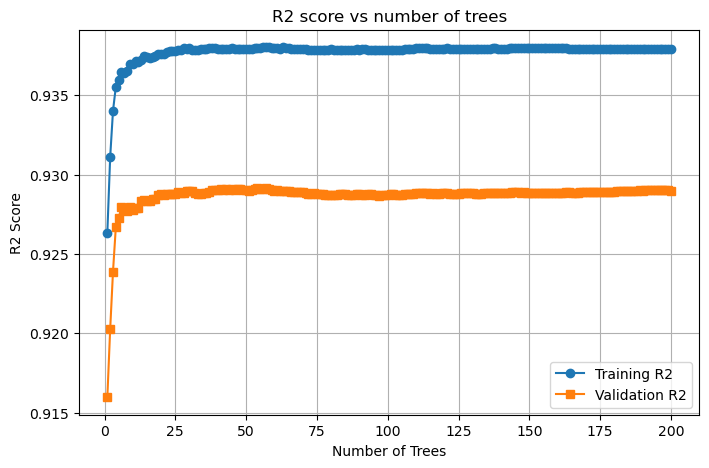

In [ ]:
#for loop to see at what n_estimators the validation error converges

X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
upper_bound_n_trees=201
x_axis= range(1,upper_bound_n_trees)
threshold= 1E-7 ###1E-7
train_sub_r2_scores=[]
validation_r2_scores=[]
for n_trees in x_axis:
        
        # print("Diff= ", diff)
        if(diff<threshold):
                print(f"Converged at {n_trees-1} trees")
                ideal_n_trees= n_trees-1
                break


        #Bagging
        model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

        ##Training
        model.fit(X_train_sub, y_train_sub)

        train_sub_r2= model.score(X_train_sub, y_train_sub)
        validation_r2 = model.score(X_val, y_val)

        train_sub_r2_scores.append(train_sub_r2)
        validation_r2_scores.append(validation_r2)

        diff= abs(validation_r2 - prev_validation_r2_score)
        prev_validation_r2_score=validation_r2

n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
print(f"Best validation R² score: {max(validation_r2_scores)}")

if(diff>=threshold):
                ideal_n_trees= upper_bound_n_trees-1

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
plt.xlabel('Number of Trees')
plt.ylabel('R2 Score')
plt.title('R2 score vs number of trees')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# #for loop to see at what min_samples_leaf the test error converges

# prev_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
# diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
# x_axis= range(1,1001)
# threshold= 1E-7
# test_r2_scores=[]
# max_r2_score=0


# for min_samples_in_leaf in x_axis:
        
#         print("Diff= ", diff)
#         # if(diff<threshold):
#         #         print(f"Converged at {min_samples_in_leaf-1} min_samples_in_leaf")
#         #         ideal_min_samples_in_leaf= min_samples_in_leaf-1
#         #         break


#         #Bagging
#         model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=bestDepth, n_estimators=ideal_n_trees, oob_score=False, min_samples_leaf=min_samples_in_leaf) #can set verbose=2 to see the steps 

#         ##Training
#         model.fit(X_train, y_train)

#         ##Prediction
#         y_pred = model.predict(X_test)

#         #Error Analysis on TEST data
#         r2 = r2_score(y_test, y_pred)
#         print(f"For {min_samples_in_leaf} min_samples_in_leaf, R² score:", r2)

#         test_r2_scores.append(r2)
#         diff= abs(r2 - prev_r2_score)
#         prev_r2_score=r2

#         if (r2>max_r2_score):
#                 max_r2_score=r2
#                 best_min_samples_in_leaf=min_samples_in_leaf
        



# plt.plot(range(1, len(test_r2_scores)+1 ), test_r2_scores)
# plt.grid()
# plt.xlabel("Number of min_samples_in_leaf")
# plt.ylabel("R2 Scores (Test data)")
# plt.title("R2 with number of min_samples_in_leaf")
# plt.show()

# print("Best min samples in a leaf node: ", best_min_samples_in_leaf)


In [ ]:
#Bagging

model = RandomForestRegressor(n_jobs=-1, random_state=0, max_depth=best_depth, n_estimators=ideal_n_trees, oob_score=True, min_samples_leaf=best_min_samples_leaf) #can set verbose=2 to see the steps 

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

#Again, the below code is redundant
#number of off-elements in y_pred
# count=0
# for i in y_pred:
#     if i>1 or i<0:
#         # print(i)
#         count+=1
# print("incorrect count = ", count)
# print("incorrect count percent = ", 100*count/len(y_pred))
# y_pred = np.clip(y_pred, 0, 1) 

#Error Analysis on TEST data
#MSE_test
MSE_Test = np.mean((y_test - y_pred)**2)
print(f'MSE_Test: {MSE_Test}')

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score (sklearn):", r2_sklearn)

Training- Elapsed time: 0.0322 minutes
Prediction- Elapsed time: 0.0013 minutes
MSE_Test: 0.013546093724486067
RMSE_TEST: 0.1163876871687296
mae_TEST: 0.032066258343095316
R² score (sklearn): 0.9305701591332164


In [ ]:
#Bagging ft. importance in descending order
#Sort indices by importance
sorted_idx = np.argsort(model.feature_importances_)[::-1]

#print("\nAll features sorted by importance:")
for i in sorted_idx:
    print(f"{feature_names[i]}: {model.feature_importances_[i]:.4f}")

ta: 0.7998
clw+cli: 0.1007
RH: 0.0885
cllvi+clivi: 0.0031
pfull: 0.0025
rho: 0.0017
ua: 0.0008
clon: 0.0008
clat: 0.0007
dzghalf: 0.0006
wa: 0.0005
va: 0.0002
height_2: 0.0000
height: 0.0000


Random Forest

Best number of trees (based on validation data): 93
Best validation R² score: 0.9141493366332024


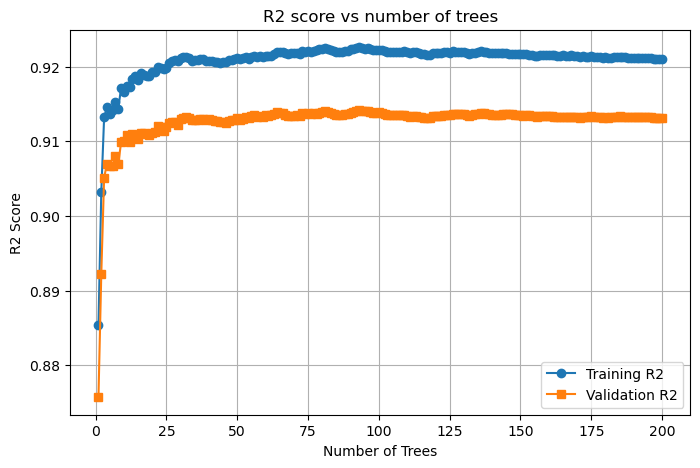

In [ ]:
#ideal num of trees for Random Forest
#for loop to see at what n_estimators the validation error converges

X_train_sub, X_val, y_train_sub, y_val=train_test_split(X_train, y_train, test_size=0.2, random_state=1)

prev_validation_r2_score=0 #Initialized arbitrarily to 0 to run the first tree in the for loop 
diff=1 # difference between R2 scores of the previous and the current tree. Initialized arbitrarily to 1 to run the first tree in the for loop 
upper_bound_n_trees=201
x_axis= range(1,upper_bound_n_trees)
threshold= 1E-7 #1E-7
train_sub_r2_scores=[]
validation_r2_scores=[]
for n_trees in x_axis:
        
        # print("Diff= ", diff)
        if(diff<threshold):
                print(f"Converged at {n_trees-1} trees")
                ideal_n_trees= n_trees-1
                break


        #Bagging
        model = RandomForestRegressor(n_jobs=-1, random_state=0, max_features=int(np.sqrt(X_train.shape[1])), max_depth=best_depth, min_samples_leaf=best_min_samples_leaf ,n_estimators=n_trees, oob_score=True) #can set verbose=2 to see the steps 

        ##Training
        model.fit(X_train_sub, y_train_sub)

        train_sub_r2= model.score(X_train_sub, y_train_sub)
        validation_r2 = model.score(X_val, y_val)

        train_sub_r2_scores.append(train_sub_r2)
        validation_r2_scores.append(validation_r2)

        diff= abs(validation_r2 - prev_validation_r2_score)
        prev_validation_r2_score=validation_r2

n_trees_for_which_max_r2 = x_axis[validation_r2_scores.index(max(validation_r2_scores))]


print(f"Best number of trees (based on validation data): {n_trees_for_which_max_r2}")
print(f"Best validation R² score: {max(validation_r2_scores)}")

if(diff>=threshold):
                ideal_n_trees= upper_bound_n_trees-1

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_sub_r2_scores)+1 ), train_sub_r2_scores, marker='o', label='Training R2')
plt.plot(range(1, len(validation_r2_scores)+1 ), validation_r2_scores, marker='s', label='Validation R2')
plt.xlabel('Number of Trees')
plt.ylabel('R2 Score')
plt.title('R2 score vs number of trees')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#Random Forest
##Training
training_start_time = time.time()
RF_condensates = RF(n_estimators=ideal_n_trees, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, max_depth=best_depth, min_samples_leaf=best_min_samples_leaf, oob_score=True).fit(X_train, y_train)
# RF_condensates = RF(n_estimators=200, max_features=int(np.sqrt(X_train.shape[1])), n_jobs=-1, random_state=0, oob_score=True).fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_hat_RF = RF_condensates.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max: ", np.max(y_hat_RF))
print("min: ", np.min(y_hat_RF))

Training- Elapsed time: 0.0183 minutes
Prediction- Elapsed time: 0.0013 minutes
max:  0.9999956553526945
min:  5.813884436180573e-13


In [ ]:
RF_condensates

,n_estimators,200
,criterion,'squared_error'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,40
,min_weight_fraction_leaf,0.0
,max_features,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [ ]:
# List of depths for all trees
tree_depths = [estimator.tree_.max_depth for estimator in model.estimators_]

# Average, min, and max depth across the forest
print("Average depth:", sum(tree_depths) / len(tree_depths))
print("Min depth:", min(tree_depths))
print("Max depth:", max(tree_depths))


Average depth: 14.0
Min depth: 14
Max depth: 14


In [ ]:
# print('size of y_hat_RF: ', len(y_hat_RF))
# count=0
# for i in y_hat_RF:
#     if(i>1 or i<0):
#         # print(i)
#         count+=1

# print('size of off-numbers: ', count)
# print('percentage of off-numbers: ', 100*count/len(y_hat_RF))
# y_hat_RF = np.clip(y_hat_RF, 0, 1) #redundant

In [ ]:
#Error Analysis on TEST data
#mse_Test
mse= np.mean((y_test- y_hat_RF)**2)
print('MSE: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_hat_RF)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_hat_RF))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_hat_RF)
print("R² score: ", r2_sklearn)

MSE:  0.016605910183281843
RMSE_TEST: 0.12886392118541887
mae_TEST: 0.04861821088310914
R² score:  0.9148872195244536


In [ ]:
#RF Ft. importance in descending order
importance = RF_condensates.feature_importances_

#Combine ft. names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.297898
pfull:0.150884
RH:0.145836
rho:0.104580
clw+cli:0.073706
height:0.069992
height_2:0.051210
clat:0.039202
dzghalf:0.036195
cllvi+clivi:0.024035
ua:0.002433
clon:0.001626
wa:0.001559
va:0.000845


Boosting

In [ ]:
#optimize learning rate, n_estimators, min_Samples_leaf, max_depth

In [ ]:
#Method 1: Using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid ={
    'n_estimators':[100,200],
    'learning_rate':[0.01, 0.1, 0.5],
    'max_depth': [5,7,10,12], #add more depths later
    'min_samples_leaf' :[10, 30] 
}

gb_model= GBR()

grid_search= GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)

print('Best parameters: ', best_params)
print(f'Best Model R2 score: {r2_best}')


Best parameters:  {'learning_rate': 0.1, 'max_depth': 12, 'min_samples_leaf': 30, 'n_estimators': 100}
Best Model R2 score: 0.9373828240783373


In [ ]:
#Method 2: Best hyperparameters using RandomizedSeachCV

# from sklearn.model_selection import RandomizedSearchCV

# param_dist ={
#     'n_estimators':[100,200],
#     'learning_rate': np.arange(0.01,0.1, 0.5),
#     'max_depth': [5,7,10,12], #add more depths later
#     'min_samples_leaf' :[10, 30] 
# }

# gb_model = GBR()

# random_search= RandomizedSearchCV(estimator=gb_model, param_distributions=param_dist, n_iter=10, cv=5, scoring='r2', n_jobs=-1)

# random_search.fit(X_train, y_train)

# best_params= random_search.best_params_
# best_model= random_search.best_estimator_

# y_pred_best= best_model.predict(X_test)
# r2_best = r2_score(y_test, y_pred_best)

# print("Best parameters: ", best_params)
# print(f"Best Model R2 Score: {r2_best}")

In [ ]:
#Use grid search's best parameters!

best_n_trees=best_params['n_estimators']
best_min_samples_leaf=best_params['min_samples_leaf']
best_max_depth=best_params['max_depth']
best_learning_rate=best_params['learning_rate']

In [ ]:
#Boosting
boost_condensates=GBR(random_state=0, n_estimators=best_n_trees, learning_rate=best_learning_rate, min_samples_leaf=best_min_samples_leaf, max_depth=best_max_depth)

##Training
training_start_time = time.time()
boost_condensates.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

Training- Elapsed time: 1.7682 minutes


Iteration 0 incorrect count =  0
incorrect count percent =  0.0
Iteration 1 incorrect count =  0
incorrect count percent =  0.0
Iteration 2 incorrect count =  0
incorrect count percent =  0.0
Iteration 3 incorrect count =  0
incorrect count percent =  0.0
Iteration 4 incorrect count =  0
incorrect count percent =  0.0
Iteration 5 incorrect count =  0
incorrect count percent =  0.0
Iteration 6 incorrect count =  0
incorrect count percent =  0.0
Iteration 7 incorrect count =  0
incorrect count percent =  0.0
Iteration 8 incorrect count =  0
incorrect count percent =  0.0
Iteration 9 incorrect count =  0
incorrect count percent =  0.0
Iteration 10 incorrect count =  0
incorrect count percent =  0.0
Iteration 11 incorrect count =  0
incorrect count percent =  0.0
Iteration 12 incorrect count =  0
incorrect count percent =  0.0
Iteration 13 incorrect count =  0
incorrect count percent =  0.0
Iteration 14 incorrect count =  0
incorrect count percent =  0.0
Iteration 15 incorrect count =  0
i

Text(0, 0.5, 'Mean Squared Error')

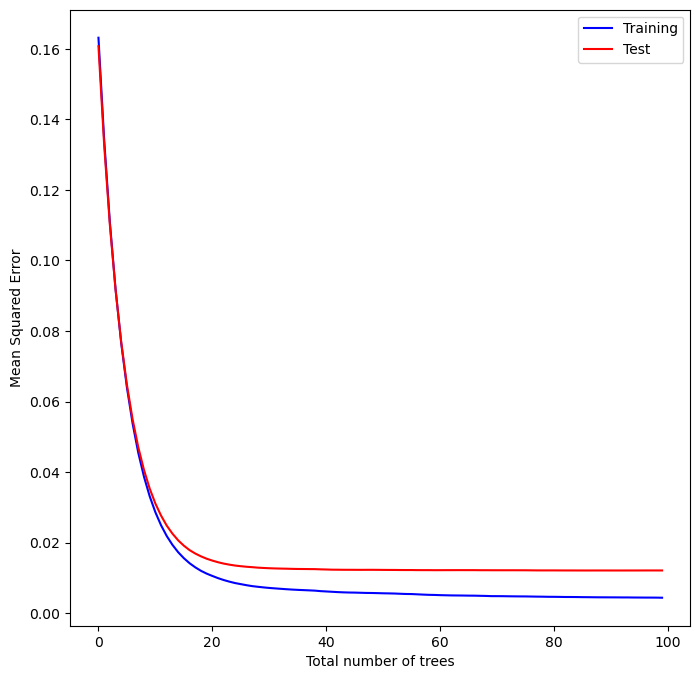

In [ ]:
#x axis: boosting iteration number
test_error = np.zeros_like(boost_condensates.train_score_)
for idx, y_ in enumerate(boost_condensates.staged_predict(X_test)):
    ######################################################
    #####################################################
    count=0
    for i in y_:
        if i>1 or i<0:
            # print(i)
            count+=1
    print(f"Iteration {idx} incorrect count = ", count)
    print("incorrect count percent = ", 100*count/len(y_))
    #####################################################
    y_ = np.clip(y_, 0, 1)
    ######################################################
    test_error[idx] = np.mean((y_test- y_)**2)
plot_idx = np.arange(boost_condensates.train_score_.shape[0])
ax = subplots(figsize=(8,8))[1]
ax.plot(plot_idx,
boost_condensates.train_score_,
'b',
label='Training')

ax.plot(plot_idx,
test_error,
'r',
label='Test')
ax.legend();

ax.set_xlabel("Total number of trees")
ax.set_ylabel("Mean Squared Error")


# print("Shape:", boost_condensates.train_score_.shape) #iterations
# print("Number of elements:", boost_condensates.train_score_.size)

In [ ]:
##Prediction
prediction_start_time = time.time()
y_hat_boost = boost_condensates.predict(X_test);
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

y_hat_boost = np.clip(y_hat_boost, 0, 1)
#Error Analysis on TEST data
#mse_test
mse= np.mean((y_test- y_hat_boost)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_hat_boost)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_hat_boost))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_hat_boost)
print("R² score: ", r2_sklearn)

Prediction- Elapsed time: 0.0006 minutes
MSE_Test:  0.012112656466292263
RMSE_TEST: 0.11005751435632309
mae_TEST: 0.02939357780047225
R² score:  0.9379171716929343


In [ ]:
#Boosting ft. importance in descending order
importance = boost_condensates.feature_importances_

#Combine ft. names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.770931
clw+cli:0.105762
RH:0.088008
cllvi+clivi:0.006146
pfull:0.004886
rho:0.004653
clat:0.004599
ua:0.003884
clon:0.003852
wa:0.002723
dzghalf:0.002440
va:0.002101
height_2:0.000016
height:0.000000


XGBoost

In [ ]:
#Method 1: Grid Search
from sklearn.model_selection import GridSearchCV

param_grid={
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10, 12],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [10, 30]
}


xgb_model= xgb.XGBRegressor()

grid_search= GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2')


grid_search.fit(X_train, y_train)

print("Best set of hyperparameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)


Best set of hyperparameters:  {'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 10, 'n_estimators': 100}
Best score:  0.9363350152969361


In [ ]:
# #n_estimators, eta/learning_rate, max_depth, min_child_weight?, max_bin (def=256)->increasing this number improves the optimality of splits at the cost of higher computation time.
# #Method 2: Random Search
# import scipy.stats as stats

# param_dist = {
#     'n_estimators': stats.randint(100, 201),
#     'max_depth': stats.randint(5,13),
#     'learning_rate': stats.uniform(0.01, 0.2),
#     'min_child_weight': stats.randint(10, 31)
#     }

# model = XGBRegressor()

# # Set up the random search with 4-fold cross validation
# random_cv = RandomizedSearchCV(random_state=1, estimator=model, param_distributions= param_dist, cv=5, n_iter=100, scoring='r2', n_jobs=-1, return_train_score= True)  #verbose=5

# random_cv.fit(X_train, y_train)

# print("Best set of hyperparameters: ", random_cv.best_params_)
# print("Best score: ", random_cv.best_score_)

Best set of hyperparameters:  {'learning_rate': np.float64(0.10347853662941044), 'max_depth': 9, 'min_child_weight': 62, 'n_estimators': 106}
Best score:  0.9368176221847534


In [ ]:
#random_cv.best_estimator_

In [ ]:
best_parameters= grid_search.best_params_

best_n_estimators=best_parameters['n_estimators']
best_min_child_weight=best_parameters['min_child_weight']
best_max_depth=best_parameters['max_depth']
best_learning_rate=best_parameters['learning_rate']

In [ ]:
#XGBoost
#later on: Boosted RF

# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

Training- Elapsed time: 0.0093 minutes
Prediction- Elapsed time: 0.0000 minutes


In [ ]:
print("max: ", np.max(y_pred))
print("min: ", np.min(y_pred))

max:  1.1650513
min:  -0.11928922


In [ ]:
count=0
for i in y_pred:
    if i>1 or i<0:
        # print(i)
        count+=1
print("incorrect count = ", count)
print("incorrect count percent = ", 100*count/len(y_pred))

incorrect count =  4213
incorrect count percent =  43.75324540450722


In [ ]:
y_pred = np.clip(y_pred, 0, 1)

In [ ]:
#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

MSE_Test:  0.012295106
RMSE_TEST: 0.11088330298662186
mae_TEST: 0.02924444153904915
R² score:  0.9369820356369019


In [ ]:
#xgb feature importance
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

for name, score in feature_scores:
    print(f'{name}:{score:.6f}')

ta:0.738755
RH:0.100675
clw+cli:0.090512
dzghalf:0.010393
pfull:0.009863
cllvi+clivi:0.009808
ua:0.007808
clon:0.007409
rho:0.007038
clat:0.006849
wa:0.006177
va:0.004711
height:0.000000
height_2:0.000000


BART

In [ ]:
#BART

# bart_condensates = BART(random_state=0, burnin=100, ndraw=15)
# bart_condensates.fit(X_train, y_train)

In [ ]:
# yhat_test = bart_condensates.predict(X_test.astype(np.float32))

# yhat_test = np.clip(yhat_test, 0, 1)
# np.mean((y_test- yhat_test)**2)

In [ ]:
# var_inclusion = pd.Series(bart_condensates.variable_inclusion_.mean(0),
#  index=D.columns)
# var_inclusion

In [ ]:
overall_end_time = time.time()

totalElapsedTime=overall_end_time - overall_start_time
print(f"The Total Elapsed Time is: {totalElapsedTime/60:.4f} minutes")

The Total Elapsed Time is: 91.2609 minutes
